# Precursor analysis — what the agent does around a multi-year ENSO onset

This notebook studies the agent's **forcing in the months surrounding** each
multi-year El Niño (MYEN) / La Niña (MYLN) onset, reading the same
`inference.npz` that `analysis.ipynb` uses.

It answers three distinct questions:

1. **Pre-onset fingerprint (few months before).** What forcing configuration
   immediately precedes an onset? This is *forecasting-relevant*, but — because the
   policy saturates — it reports the *sign/direction* of each driver, not the
   mechanism, and is essentially identical for a 3- vs 6-month window.
2. **Driving mechanism (lead-time profile, ~24 months).** *When* does the agent move
   each mode, and in what order? The real decision-making happens **~8–18 months
   out**, much of it *inside the dying opposite-phase event* (the agent recharges WWV
   for the next event — a recharge-oscillator signature). The **sequencing** of modes
   is the insight an RL agent gives that a linear precursor analysis cannot.
3. **Sustainment (24 months after onset).** Once the event has started, what forcing
   and what state evolution keep it alive long enough to count as multi-year? The
   composites in §3 and §3b span the full **−24 → +24** life cycle, so onset,
   maintenance and termination are read off one figure.

**Caveat.** This is the *agent's learned control strategy*, not a claim about
real-world ENSO precursors. Statistics are **clustered at the training-seed level**
(n≈10); naively pooling the ~6,000 events per phase would give confidence intervals
~9–29× too narrow.

In [108]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path("..").resolve()))
from utils.nb_helper import PHASE_LABELS, XRO_MODES, _mean_ci, _load_npz
from utils.enso_classifier import _find_continuous_runs
from config import EnvConfig

NAME  = "model10"                      # matches --model used when running inference
BASE  = Path("..") / "plots" / NAME
OUTDIR = BASE / "precursor"
OUTDIR.mkdir(parents=True, exist_ok=True)

LEAD  = 24                             # months BEFORE onset to analyse
POST  = 24                             # months AFTER onset: median MY duration is 23-24 mo,
                                       # 100% of events still running at +12, ~90% at +20,
                                       # ~50% at +23 -> covers the full life cycle
W     = LEAD + POST                    # composite window length
CODES = {"el_nino": 3, "la_nina": 4}   # MYE label codes (3 = MY El Niño, 4 = MY La Niña)
MODE_COLORS = dict(zip(XRO_MODES, plt.cm.tab10(np.linspace(0, 1, 10))))

plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.size": 11, "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
})

d = _load_npz(BASE / "inference.npz")
acts   = d["agent_actions"].astype(np.float64)   # [S,R,T,9] scaled forcing
labels = d["agent_mye_label"]                    # [S,R,T] int8
start_month = d["rollout_start_month"]           # [S,R] 0-based calendar month of step 0
names  = list(d["action_names"])
S, R, T, M = acts.shape
spin = int(d["spinup"])
assert names == XRO_MODES, "action-mode order mismatch"
print(f"seeds={S}  rollouts={R}  months(T)={T}  modes={M}  spinup={spin}")

seeds=10  rollouts=30  months(T)=1200  modes=9  spinup=12


## 1. Recover raw actions and de-seasonalize

Stored `agent_actions` are scaled by the per-mode, per-month `action_scale` (indexed
by `step % 12` at write time). Dividing by that **same** factor recovers the raw
policy action in `[-1, 1]` and cancels the known month-offset scaling bug exactly
(this mirrors the correct cells 29/30 of `analysis.ipynb`).

We also build a de-seasonalized copy, `anom`, by subtracting each mode's
climatological mean action **by true calendar month** `(step + rollout_start_month) %
12`. The composites in §3 are plotted **raw**, so the policy's learned seasonal
behaviour is retained; `anom` and its climatology `clim` are kept as the check that
the composite structure is not a seasonal artefact (see §3), and `clim` is itself the
policy's learned seasonal cycle if you want to plot it.

In [109]:
# Raw policy action in [-1, 1]
scale = np.array(EnvConfig().action_scale)              # [9,12], already halved in __post_init__
raw = acts / scale[:, np.arange(T) % 12].T              # [S,R,T,9]
assert raw.min() >= -1.001 and raw.max() <= 1.001, "raw action outside [-1,1]"

# De-seasonalize by TRUE calendar month
cal = (np.arange(T)[None, None, :] + start_month[:, :, None]) % 12   # [S,R,T]
keep = np.arange(T) >= spin
clim = np.stack([raw[(cal == m) & keep[None, None, :]].mean(0) for m in range(12)])  # [12,9]
anom = raw - clim[cal]                                   # [S,R,T,9]

print(f"raw range = [{raw.min():.3f}, {raw.max():.3f}]")
print(f"saturation |raw|>0.99 (post-spinup) = {100*(np.abs(raw[:,:,spin:])>0.99).mean():.1f}%"
      "  -> composites mostly report SIGNS, not graded magnitudes")

raw range = [-1.000, 1.000]
saturation |raw|>0.99 (post-spinup) = 74.6%  -> composites mostly report SIGNS, not graded magnitudes


## 2. Locate multi-year event onsets

For each `(seed, rollout)` we find every contiguous run of a phase label; each run's
start index is that event's **onset**. We keep only onsets whose full `LEAD`-month
pre-window clears the spin-up **and** whose full `POST`-month post-window fits inside
the rollout — the same event set is then used by every section below. Requiring the
post-window costs ~0.9% of onsets.

In [110]:
events = {p: [] for p in CODES}                  # p -> list of (si, ri, t0)
for p, code in CODES.items():
    for si in range(S):
        for ri in range(R):
            for s0, e0, L in _find_continuous_runs((labels[si, ri] == code).astype(int)):
                if s0 - LEAD >= spin and s0 + POST <= T:
                    events[p].append((si, ri, s0))
for p in CODES:
    print(f"{PHASE_LABELS[p]:22s}: {len(events[p]):5d} onset events "
          f"(full -{LEAD}/+{POST}-mo window)")

Multi-year El Niño    :  6065 onset events (full -24/+24-mo window)
Multi-year La Niña    :  6056 onset events (full -24/+24-mo window)


## 3. Event life-cycle driver profile — primary result

For every mode we composite the **raw policy action** over the 24 months before onset
*and* the 24 months after it. We aggregate **per seed first**, then take the mean and
95% CI **across seeds** (the correct clustering). The left half answers *when does the
agent commit each driver*; the right half answers *what keeps the event alive once it
has started*.

**Why raw and not de-seasonalized.** Actions are plotted as-is so the policy's own
seasonal behaviour stays in the figure. This is safe here because onsets are spread
across the calendar — the modal onset month holds only 15–16% of events (uniform =
8.3%) — so each lag averages over all 12 calendar months and the seasonal cycle is
largely composited away regardless. The de-seasonalized version (`anom`, cell 3) is
kept as the check: it correlates with the raw composite at **r ≥ 0.998** for all nine
modes, no curve shifts by more than 0.21, and the onset-time sign is identical 9/9 in
both phases. The policy's learned seasonal cycle is small in any case — swing over the
year is 0.15 (SASD), 0.13 (SIOD), 0.12 (IOD), 0.11 (WWV) and ≤0.07 for the rest, on a
±1 action range.

**Reading the post-onset half.** This is a fixed-window composite over all onsets — no
survival conditioning, which would bias the sample toward the longest events — so once
events start terminating the average mixes in months after the event. The cell prints
the share still inside the event by lag; for the caption: **100% through +12, ~96% at
+18, ~90% at +20, 46–57% at +23**. The driver sign reversals all occur while that
share is still 100%, so the main post-onset result does not depend on the tail.
Events do not fade into a long neutral tail either: they drop to Neutral for about a
month and then **70–77% flip into the opposite multi-year phase within 6 months**,
which is why the drivers reverse sign near the right edge — that reversal *is* the
next event's recharge (§6).

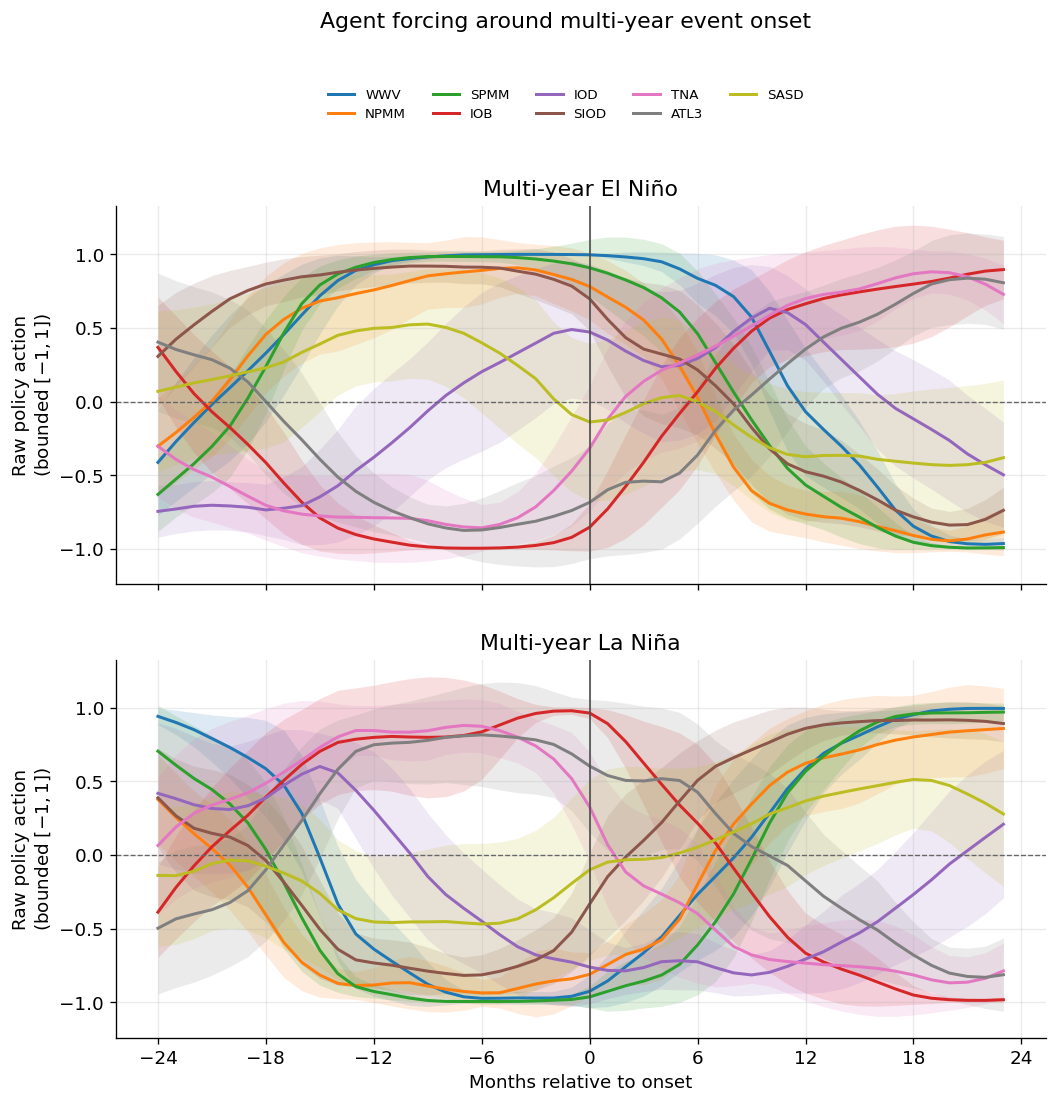

Multi-year El Niño    : still in event at +12/+18/+20/+23 mo = 100% / 96% / 89% / 46%
Multi-year La Niña    : still in event at +12/+18/+20/+23 mo = 100% / 95% / 90% / 57%


In [111]:
def leadtime_profile(ev, arr):
    # Seed-clustered life-cycle composite over arr's last axis (9 actions or 10 states).
    # Returns mean[W,K], ci[W,K] for lags -LEAD .. +POST-1.
    K = arr.shape[-1]
    per_seed = np.full((S, W, K), np.nan)
    for si in range(S):
        wins = [arr[s, r, t0 - LEAD:t0 + POST, :] for (s, r, t0) in ev if s == si]
        if wins:
            per_seed[si] = np.mean(wins, axis=0)
    mean = np.full((W, K), np.nan); ci = np.full((W, K), np.nan)
    for k in range(W):
        for i in range(K):
            col = per_seed[~np.isnan(per_seed[:, k, i]), k, i]
            if len(col) > 1:
                mean[k, i], ci[k, i] = _mean_ci(col)
    return mean, ci

def survival(p):
    # % of composited events still inside the event, by post-onset lag. Not drawn on the
    # figures (kept clean) -- report it in the caption instead.
    return 100 * (np.stack([labels[s, r, t0:t0 + POST]
                            for (s, r, t0) in events[p]]) == CODES[p]).mean(0)

def mark_lifecycle(ax, p):
    ax.axvline(0, color="0.3", lw=1.0)                       # onset
    ax.set_xticks(np.arange(-LEAD, POST + 1, 6))             # 6-month grid

def lifecycle_legend(fig, ax, ncol):
    h, l = ax.get_legend_handles_labels()
    fig.legend(h, l, ncol=ncol, fontsize=8, frameon=False,
               loc="upper center", bbox_to_anchor=(0.5, 1.0))

# RAW actions (not de-seasonalized): the policy's own seasonal behaviour is kept in.
# `anom` above stays available as the seasonality check -- see the markdown.
prof = {p: leadtime_profile(events[p], raw) for p in CODES}
lags = np.arange(-LEAD, POST)

fig, axes = plt.subplots(2, 1, figsize=(10, 9), sharex=True, sharey=True)
for ax, p in zip(axes, CODES):
    mean, ci = prof[p]
    for mi, nm in enumerate(names):
        ax.plot(lags, mean[:, mi], color=MODE_COLORS[nm], lw=1.8, label=nm)
        ax.fill_between(lags, mean[:, mi] - ci[:, mi], mean[:, mi] + ci[:, mi],
                        color=MODE_COLORS[nm], alpha=0.15, lw=0)
    ax.axhline(0, color="0.4", lw=0.8, ls="--")
    mark_lifecycle(ax, p)
    ax.set_title(PHASE_LABELS[p]); ax.set_ylabel("Raw policy action\n(bounded $[-1, 1]$)")
axes[-1].set_xlabel("Months relative to onset")
lifecycle_legend(fig, axes[0], 5)
fig.suptitle("Agent forcing around multi-year event onset", y=1.06)
fig.savefig(OUTDIR / "07a_precursor_leadtime.png")
plt.show()

# For the figure caption: how much of the composite is still inside the event.
for p in CODES:
    sv = survival(p)
    print(f"{PHASE_LABELS[p]:22s}: still in event at +12/+18/+20/+23 mo = "
          + " / ".join(f"{sv[k]:.0f}%" for k in (12, 18, 20, 23)))

**What the figure shows**

- **A fixed sign pattern at onset.** At lag 0 the agent drives WWV, NPMM, SPMM, IOD
  and SIOD *with* the event and IOB, ATL3, TNA *against* it (MYEN: +1.00, +0.78, +0.91,
  +0.47, +0.70 vs −0.85, −0.68, −0.32). The two panels are near mirror images —
  correlation of MYEN against sign-flipped MYLN is **r = 0.93** over the whole window,
  so this is one strategy run in two directions, not two strategies.
- **Read signs, not magnitudes.** 74.6% of raw actions sit at |a| > 0.99, so a curve at
  ±0.8 means "nearly every event is saturated in this direction", not "moderate
  forcing". Departures from ±1 mostly reflect disagreement on *timing* across events
  and seeds, not intermediate action values.
- **Commitment is early and ordered.** Reading backwards from onset, drivers settle
  into their onset sign at SIOD/TNA ≥24 months (MYEN), NPMM/IOB 21–22, WWV 16–21,
  SPMM 18–20, ATL3 18–19, and IOD only 9–10 (§5). The inter-basin modes are set well
  over a year ahead; IOD is the late adjustment.
- **Release is fast, and happens mid-event.** After onset the drivers flip sign at TNA
  **+2**, SIOD +3–8, SASD +4–5, IOB +6–8, NPMM +7, SPMM/ATL3 +9–10, WWV **+9–12**, IOD
  +17–21. By roughly +12 months the configuration has reversed while **100% of events
  are still running** — the agent stops pushing long before the event ends.
- **Left and right edges are the same state, one cycle apart.** At −24 the drivers
  already sit at the opposite sign, and by ~+20 they have returned there. The window
  spans roughly one full oscillation, so the post-onset reversal is not the event
  decaying under continued forcing — it is the recharge of the next, opposite event
  (§6).
- **Seeds agree on the core, not the periphery.** Mean CI half-width is ~0.19 for
  WWV/SPMM and ~0.25 for NPMM, against **0.48–0.50 for SASD** and 0.33–0.39 for ATL3
  and IOD. The WWV/SPMM/NPMM strategy is universal across training seeds; the South
  Atlantic and Indian Ocean dipole handling is seed-specific and should not be
  over-interpreted.
- **Seasonality is inside these curves but barely visible.** Actions are plotted raw,
  so any learned seasonal preference is retained — however, because onsets spread
  across the calendar, each lag averages over all 12 months and the seasonal signal
  largely cancels. The policy's seasonal swing is ≤0.15 on a ±1 range in any case; to
  see it directly, plot `clim` from cell 3 against calendar month rather than reading
  it off this figure.

### 3b. The same view for the *state* variables

The panel above is what the agent **does**; this one is what the climate **is** while
it does it. Same events, same −24 → +24 window, same seed-clustered mean ± 95% CI —
now compositing `agent_obs` (Niño3.4 plus the nine XRO modes).

**Referenced to the baseline, not to the agent.** Each variable is centred on the mean
and divided by the σ of `base_obs` — the same XRO model, same rollout seeds, no agent.
Zero therefore means *what the uncontrolled model does*, and one unit is one σ of
**unforced model variability**. This matters: the agent inflates variability by
1.8–2.7× (83.7% of its months sit inside a multi-year event, versus 34.8% for the
baseline), so normalising by the agent's own spread would measure the agent against
itself and roughly halve the apparent effect.

**"Unforced model", not "natural".** The baseline is the XRO model, not the observed
record, and it **under-disperses**: against ORAS5 (1979–2024) its σ ratio is 0.78 for
Niño3.4, 0.70–0.75 for the SST modes, **0.59 for IOD**, and only WWV matches (1.02).
So a curve at *k* σ here is roughly **0.75 k σ of observed variability** — divide by
the ratios in §7 before making any claim against the real world. (The baseline also
produces multi-year events far more often than observations: 34.8% of months vs 22.1%
in ORAS5.)

**Not de-seasonalized.** The XRO variables are already anomaly indices, so their
seasonal cycle in the *mean* is just 2–6% of σ — removing it changes nothing visible.
The seasonality that is real here lives in the *variance* (baseline Niño3.4 spread is
0.61 in April against 0.81 in November–December, and IOD varies 2.0× over the year).
That is ENSO's seasonal phase locking; subtracting monthly means would not remove it
anyway, and it is left in deliberately since the agent plausibly exploits it.

Colors match the driver plot mode-for-mode, so the two figures can be read side by side
(forcing vs. response); Niño3.4, which has no action counterpart, is the thick black
curve. To convert back to physical units, multiply by the baseline σ the cell prints
(Niño3.4 = 0.70 °C, WWV = 7.11, IOB = 0.18 °C, …).

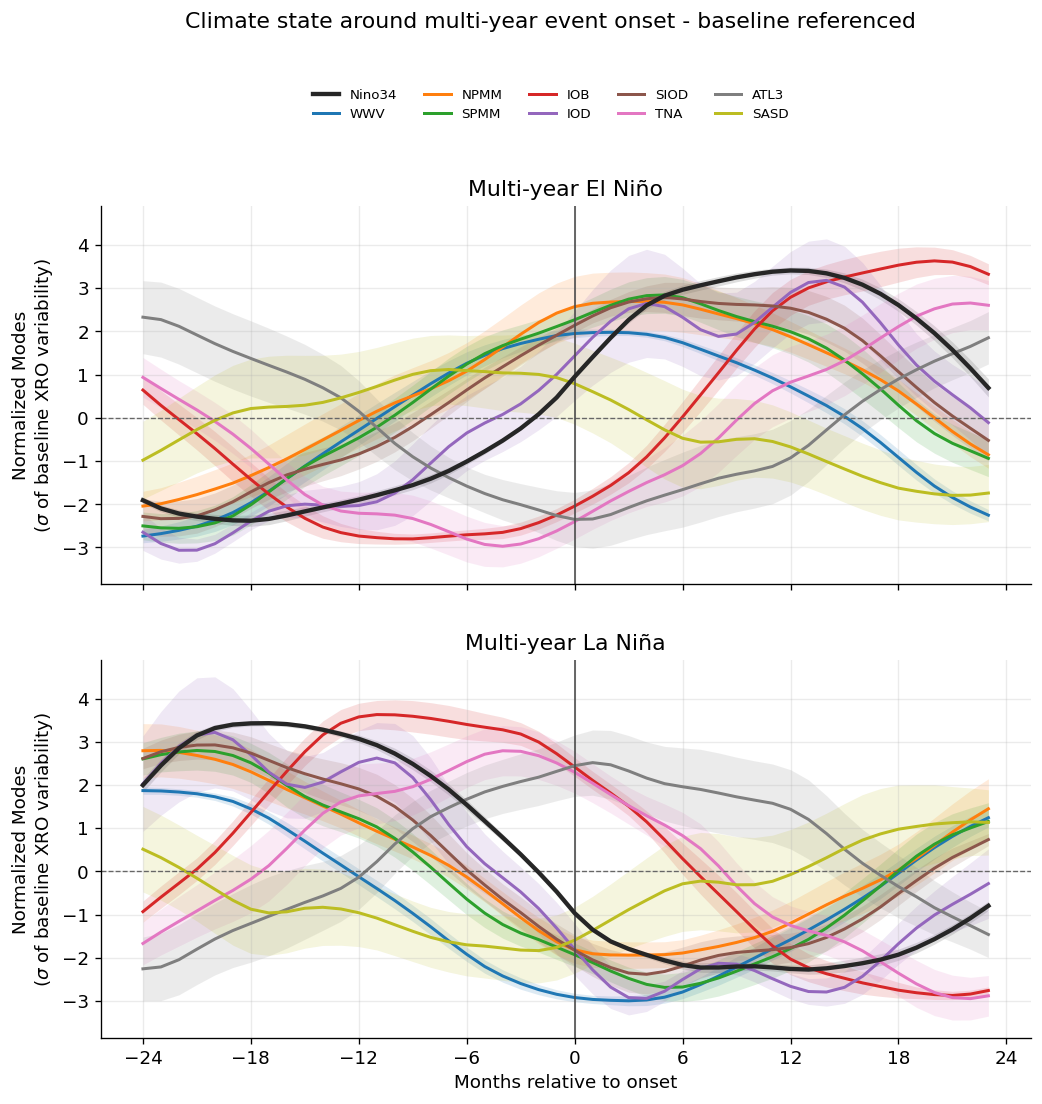

baseline (unforced) sigma used to normalize -- multiply curves by this for physical units:
  Nino34=0.70  WWV=7.11  NPMM=0.31  SPMM=0.33  IOB=0.18  IOD=0.28  SIOD=0.28  TNA=0.27  ATL3=0.33  SASD=0.38


In [112]:
vnames = list(d["var_names"])                            # Nino34 + the 9 XRO modes
V = len(vnames)

# States are referenced to the BASELINE: the same XRO model, same rollout seeds, no
# agent. Zero = "what the uncontrolled model does", and the unit is one sigma of
# UNFORCED MODEL variability -- not observed variability (the model under-disperses
# vs ORAS5 by ~25%, IOD by 41%; see the check in section 7).
#
# Normalising by the agent's own spread instead would measure the agent against itself
# and roughly halve the apparent effect (agent sigma is 1.8-2.7x baseline).
#
# No de-seasonalizing: the XRO variables are already anomaly indices, so their seasonal
# cycle in the MEAN is only 2-6% of sigma. The seasonality that is real here lives in
# the VARIANCE (baseline Nino34 spread 0.61 in Apr vs 0.81 in Nov-Dec) -- that is ENSO
# phase locking, and it is deliberately left in.
obs  = d["agent_obs"].astype(np.float64)                 # [S,R,T,10] physical units
base = d["base_obs"].astype(np.float64)                  # paired no-agent control
bmu  = base[:, :, spin:].mean(axis=(0, 1, 2))            # [10] unforced mean
bsig = base[:, :, spin:].std(axis=(0, 1, 2))             # [10] unforced sigma
vanom = (obs - bmu) / bsig                               # -> sigma of unforced variability

VAR_COLORS = {**MODE_COLORS, "Nino34": "0.15"}           # modes keep their driver-plot color

sprof = {p: leadtime_profile(events[p], vanom) for p in CODES}

fig, axes = plt.subplots(2, 1, figsize=(10, 9), sharex=True, sharey=True)
for ax, p in zip(axes, CODES):
    mean, ci = sprof[p]
    for vi, nm in enumerate(vnames):
        top = nm == "Nino34"
        ax.plot(lags, mean[:, vi], color=VAR_COLORS[nm], lw=2.6 if top else 1.8,
                zorder=3 if top else 2, label=nm)
        ax.fill_between(lags, mean[:, vi] - ci[:, vi], mean[:, vi] + ci[:, vi],
                        color=VAR_COLORS[nm], alpha=0.15, lw=0)
    ax.axhline(0, color="0.4", lw=0.8, ls="--")
    mark_lifecycle(ax, p)
    ax.set_title(PHASE_LABELS[p])
    ax.set_ylabel("Normalized Modes\n($\\sigma$ of baseline XRO variability)")
axes[-1].set_xlabel("Months relative to onset")
lifecycle_legend(fig, axes[0], 5)
fig.suptitle("Climate state around multi-year event onset - baseline referenced", y=1.06)
fig.savefig(OUTDIR / "07c_precursor_leadtime_state.png")
plt.show()

print("baseline (unforced) sigma used to normalize -- multiply curves by this for physical units:")
print("  " + "  ".join(f"{nm}={bsig[i]:.2f}" for i, nm in enumerate(vnames)))

**What the figure shows** — all values in σ of *unforced model* (baseline) variability

- **The agent drives the system far outside its unforced range.** Niño3.4 peaks at
  **+3.4 σ** (MYEN, +2.4 °C) and **−2.3 σ** (MYLN, −1.6 °C) at +12/+13 months, and
  every other variable reaches 2–3 σ somewhere in the cycle. Against *observed*
  variability that peak is ≈2.7 σ (2.4 °C / 0.89 °C) — still a large excursion, but
  quote the observed number, not the model one, in any real-world comparison.
- **Onset is the threshold crossing, not the peak.** Niño3.4 is only **+0.95 σ** at lag
  0 (−0.97 σ for MYLN) and takes another year to peak. It never crosses zero inside the
  window — events end by falling back through the ±0.5 °C threshold, not by flipping
  sign.
- **The state is already loaded before onset.** At lag 0 the inter-basin modes are
  further from normal than Niño3.4 itself: TNA −2.40 σ, ATL3 −2.35 σ, NPMM +2.57 σ,
  SPMM +2.27 σ, SIOD +2.14 σ, IOB −2.04 σ, WWV +1.95 σ (MYEN).
- **WWV loads early and then reverses hard.** It peaks at **+2/+3 months** (+1.98 σ
  MYEN), crosses zero at **+16/+19** and ends the window at **−2.25 σ** — a full
  discharge and overshoot into the opposite phase, ~10 months before Niño3.4 has
  finished decaying. Recharge before, discharge during: the recharge-oscillator
  ordering, learned rather than imposed. WWV is also the one variable whose model σ
  matches observations (ratio 1.02), so its σ values need no discount.
- **Forcing and response are decoupled after onset.** Compare with the panel above: the
  drivers have all reversed by ~+12, yet Niño3.4 is still growing. Sustainment comes
  from the ocean state the forcing already built, not from continued forcing.
- **Two response clocks.** Subtropical/meridional modes peak early with WWV — NPMM +3,
  SIOD +4/+5, SPMM +5 — and cross back through zero by +18–22. The inter-basin
  responses peak *last*: IOB **+20/+21**, TNA **+22**, SASD +21, i.e. 8–10 months after
  Niño3.4, the capacitor-like lag.
- **The two Atlantic indices sit at opposite ends.** ATL3 is already at its extreme *at*
  onset (−2.35 σ MYEN, +2.52 σ at +1 for MYLN) and relaxes through zero at +15/+17,
  while TNA is still building at the right edge — "the Atlantic" is not one signal here.
- **The agent also shifts the mean climate.** Averaged over all months, the controlled
  system sits at **+0.28 σ** in Niño3.4, +0.38 σ NPMM, +0.29 σ SIOD and **−0.41 σ** WWV
  relative to the unforced model. Part of the El Niño/La Niña amplitude gap (3.4 vs
  2.3 σ) is this offset rather than stronger El Niño dynamics.
- **Confidence tracks centrality.** Mean CI half-width is **0.09–0.10 σ for Niño3.4**
  and 0.18–0.20 σ for WWV, against **0.91–0.92 σ for SASD**, 0.72–0.77 σ for ATL3 and
  0.65–0.76 σ for IOD. Seeds converge on the same Pacific evolution and disagree mainly
  on the South Atlantic. Phase antisymmetry is **r = 0.95**.

*Two units caveats.* (1) Each curve is divided by its **own** baseline σ, so heights are
not comparable across curves — 3.6 σ of IOB is 0.65 °C while 3.4 σ of Niño3.4 is 2.4 °C.
(2) The baseline is the **unforced XRO model, not observations**, and it under-disperses
by ~25% (IOD by 41%); §7 prints the per-variable conversion.

### 3c. The same states, normalized by the *agent's own* distribution

Identical composite, identical events — only the reference changes. Here each variable
is centred and scaled by the mean and σ of `agent_obs` itself, instead of the no-agent
baseline. **Open question for discussion; §3b is the version currently used elsewhere
in this notebook.**

| | §3b — baseline σ | §3c — agent σ |
|---|---|---|
| zero means | what the climate does **unforced** | a **typical month under the agent** |
| the unit is | one σ of unforced variability | one σ of the *controlled* world |
| question answered | *how far did the agent push the climate?* | *how unusual is this event among the agent's own months?* |
| Niño3.4 peak | **3.41** | **1.40** |

Three things to weigh:

1. **The agent-referenced version is self-referential.** 83.7% of the agent's months
   sit inside a multi-year event, so its σ is inflated by the very behaviour being
   measured — the effect is divided partly by itself. That is why everything collapses
   toward ~1.2–1.4 σ.
2. **The rescaling is uneven and zero moves, so apparent rankings change.** The ratio
   agent-σ/baseline-σ runs from 1.84 (SASD) to 2.67 (IOD), and the agent's mean differs
   from the baseline's by up to 0.41 σ. Ranked by |peak|, IOD is **3rd** under the
   baseline reference and **8th** under the agent reference — same data, different story
   about which basin matters.
3. **The agent's mean shift disappears.** Centring on the agent's own mean removes, by
   construction, the finding that the controlled climate sits +0.28 σ warmer in
   Niño3.4 (and −0.41 σ in WWV) than the unforced one.

**What is and is not invariant.** Both maps are `x → (x − μ)/σ` with σ > 0, so each
curve's *shape* is preserved exactly (correlation = 1.000000) and its own maximum and
minimum lags cannot move — the sequencing argument (WWV first, Niño3.4 at +12, IOB and
TNA last) holds under either reference. What *does* move is **which extreme is largest
in absolute value**, because |x| is measured from zero and the two references put zero
in different places: it changes for WWV, NPMM, SPMM, SIOD and TNA. So rank variables by
their peak only after fixing the reference, and never treat a |peak| ranking as a
property of the data alone.

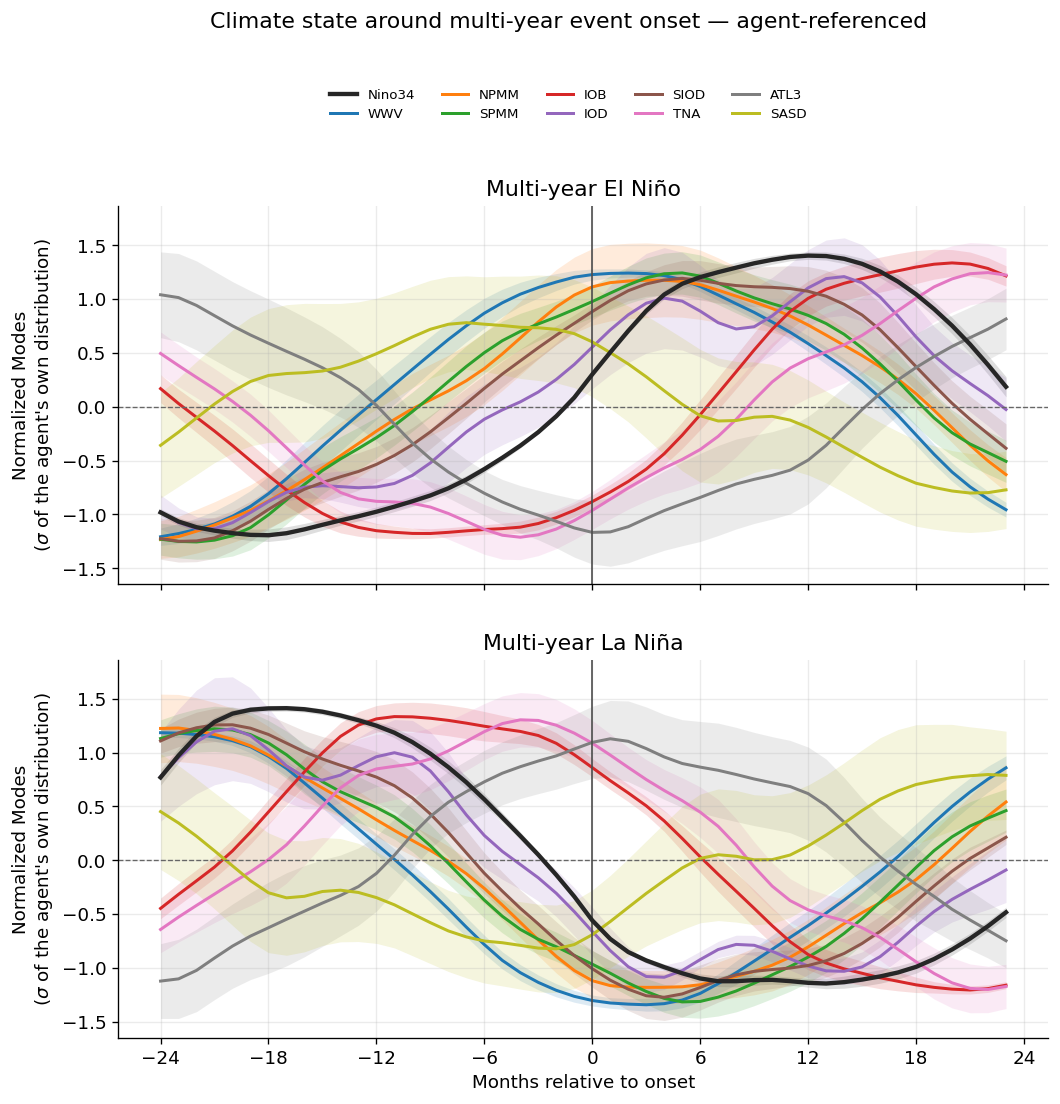

invariant across references: {'shape corr == 1': np.float64(0.9999999999999998), 'argmax(x) same': True, 'argmin(x) same': True}
argmax|x| MOVES for: [np.str_('NPMM'), np.str_('SIOD'), np.str_('SPMM'), np.str_('TNA'), np.str_('WWV')]  <- reference-dependent, do not rank on it



,agent_sigma,baseline_sigma,ratio,peak_agent_ref,peak_base_ref,rank_agent_ref,rank_base_ref
variable,,,,,,,
Nino34,1.56,0.70,2.23,1.40,3.41,1,2
WWV,13.68,7.11,1.93,1.24,-2.74,6,7
NPMM,0.60,0.31,1.97,-1.23,2.69,7,8
SPMM,0.71,0.33,2.16,-1.26,2.84,3,5
IOB,0.46,0.18,2.56,1.34,3.63,2,1
IOD,0.75,0.28,2.67,1.21,3.18,8,3
SIOD,0.59,0.28,2.10,-1.25,2.79,4,6
TNA,0.61,0.27,2.29,1.25,-2.97,4,4
ATL3,0.69,0.33,2.12,-1.17,-2.35,9,9


In [113]:
# ALTERNATIVE REFERENCE: agent's own distribution instead of the no-agent baseline.
# Same events, same window, same layout as 3b -- only bmu/bsig are swapped for the
# agent's own mean/sigma, so the two figures can be compared directly.
amu  = obs[:, :, spin:].mean(axis=(0, 1, 2))             # [10] agent's own mean
asig = obs[:, :, spin:].std(axis=(0, 1, 2))              # [10] agent's own sigma
vanom_a = (obs - amu) / asig

sprof_a = {p: leadtime_profile(events[p], vanom_a) for p in CODES}

fig, axes = plt.subplots(2, 1, figsize=(10, 9), sharex=True, sharey=True)
for ax, p in zip(axes, CODES):
    mean, ci = sprof_a[p]
    for vi, nm in enumerate(vnames):
        top = nm == "Nino34"
        ax.plot(lags, mean[:, vi], color=VAR_COLORS[nm], lw=2.6 if top else 1.8,
                zorder=3 if top else 2, label=nm)
        ax.fill_between(lags, mean[:, vi] - ci[:, vi], mean[:, vi] + ci[:, vi],
                        color=VAR_COLORS[nm], alpha=0.15, lw=0)
    ax.axhline(0, color="0.4", lw=0.8, ls="--")
    mark_lifecycle(ax, p)
    ax.set_title(PHASE_LABELS[p])
    ax.set_ylabel("Normalized Modes\n($\\sigma$ of the agent's own distribution)")
axes[-1].set_xlabel("Months relative to onset")
lifecycle_legend(fig, axes[0], 5)
fig.suptitle("Climate state around multi-year event onset — agent-referenced", y=1.06)
fig.savefig(OUTDIR / "07d_precursor_leadtime_state_agentref.png")
plt.show()

# What is invariant between the two references, and what is not.
# Both maps are x -> (x - mu)/sigma with sigma > 0, so each curve's SHAPE is preserved
# exactly and its own max/min lags cannot move. But |x| is measured from zero, and the
# two references put zero in different places -- so "which extreme is largest in
# absolute value" CAN move, and with it any ranking built on |peak|.
inv = {"shape corr == 1": min(np.corrcoef(sprof_a[p][0][:, i], sprof[p][0][:, i])[0, 1]
                              for p in CODES for i in range(V)),
       "argmax(x) same":  all(np.argmax(sprof_a[p][0][:, i]) == np.argmax(sprof[p][0][:, i])
                              for p in CODES for i in range(V)),
       "argmin(x) same":  all(np.argmin(sprof_a[p][0][:, i]) == np.argmin(sprof[p][0][:, i])
                              for p in CODES for i in range(V))}
moved = [vnames[i] for p in CODES for i in range(V)
         if np.argmax(np.abs(sprof_a[p][0][:, i])) != np.argmax(np.abs(sprof[p][0][:, i]))]
print(f"invariant across references: {inv}")
print(f"argmax|x| MOVES for: {sorted(set(moved))}  <- reference-dependent, do not rank on it\n")

# Side-by-side of the two references, for the discussion (MYEN panel).
def peak_abs(pr, i):
    col = pr["el_nino"][0][:, i]
    return float(col[np.argmax(np.abs(col))])

cmp = pd.DataFrame({
    "agent_sigma":    asig,
    "baseline_sigma": bsig,
    "ratio":          asig / bsig,
    "peak_agent_ref": [peak_abs(sprof_a, i) for i in range(V)],
    "peak_base_ref":  [peak_abs(sprof,   i) for i in range(V)],
}, index=vnames).round(2)
cmp["rank_agent_ref"] = cmp.peak_agent_ref.abs().rank(ascending=False).astype(int)
cmp["rank_base_ref"]  = cmp.peak_base_ref.abs().rank(ascending=False).astype(int)
cmp.index.name = "variable"
cmp.to_csv(OUTDIR / "state_reference_comparison.csv")
cmp

## 4. Pre-onset fingerprint table

Mean **raw** action over the 3- and 6-month windows immediately before onset, per
mode and phase, with seed-clustered 95% CIs. Because the policy is saturated, this is
the pre-onset *fingerprint* (direction of each driver). The 3- and 6-month columns
agree in sign on all 9 modes — the window length does not matter here.

In [114]:
def fingerprint(ev, arr, L):
    per_seed = np.full((S, M), np.nan)
    for si in range(S):
        wins = [arr[s, r, t0 - L:t0, :].mean(0) for (s, r, t0) in ev if s == si]
        if wins:
            per_seed[si] = np.mean(wins, axis=0)
    return {mi: _mean_ci(per_seed[~np.isnan(per_seed[:, mi]), mi]) for mi in range(M)}

rows = []
for p in CODES:
    for L in (3, 6):
        fp = fingerprint(events[p], raw, L)
        for mi, nm in enumerate(names):
            m, c = fp[mi]
            rows.append(dict(phase=p, window_mo=L, mode=nm, mean=round(m, 3), ci95=round(c, 3)))
fp_df = pd.DataFrame(rows)
fp_df.to_csv(OUTDIR / "precursor_fingerprint.csv", index=False)

for p in CODES:
    s3 = fp_df[(fp_df.phase == p) & (fp_df.window_mo == 3)].set_index("mode")["mean"]
    s6 = fp_df[(fp_df.phase == p) & (fp_df.window_mo == 6)].set_index("mode")["mean"]
    print(f"{PHASE_LABELS[p]}: 3-mo vs 6-mo sign agreement = {int((np.sign(s3)==np.sign(s6)).sum())}/9")

# Readable pivot: modes x (phase, window)
pivot = fp_df.pivot_table(index="mode", columns=["phase", "window_mo"], values="mean").reindex(XRO_MODES)
pivot

Multi-year El Niño: 3-mo vs 6-mo sign agreement = 9/9
Multi-year La Niña: 3-mo vs 6-mo sign agreement = 9/9


phase     el_nino        la_nina       
window_mo       3      6       3      6
mode                                   
WWV         0.999  0.998  -0.966 -0.969
NPMM        0.862  0.881  -0.856 -0.890
SPMM        0.952  0.967  -0.985 -0.989
IOB        -0.952 -0.973   0.973  0.929
IOD         0.450  0.358  -0.703 -0.620
SIOD        0.826  0.864  -0.628 -0.707
TNA        -0.597 -0.712   0.638  0.739
ATL3       -0.777 -0.815   0.740  0.774
SASD        0.028  0.176  -0.284 -0.369

## 5. Driver sequencing

For each mode, the lead (months before onset) at which its de-seasonalized composite
**last settled into its onset-time sign** — i.e. how early the agent commits that
driver. Modes near the top act earliest.

In [115]:
def sequencing(ev, arr):
    mean, _ = leadtime_profile(ev, arr)
    out = {}
    for mi, nm in enumerate(names):
        col = mean[:LEAD, mi]                            # pre-onset half only
        diff = np.where(np.sign(col) != np.sign(col[-1]))[0]
        out[nm] = float(LEAD) if len(diff) == 0 else float(LEAD - diff[-1])  # >LEAD -> LEAD
    return out

# raw actions, matching the figure in §3 (de-seasonalizing moves these by <=4 months)
seq_df = pd.DataFrame({PHASE_LABELS[p]: sequencing(events[p], raw) for p in CODES}).reindex(XRO_MODES)
seq_df.index.name = "mode  (settling lead, months before onset; =24 means >24)"
seq_df.to_csv(OUTDIR / "precursor_sequencing.csv")
seq_df.sort_values(seq_df.columns[0], ascending=False)

,Multi-year El Niño,Multi-year La Niña
"mode (settling lead, months before onset; =24 means >24)",,
SIOD,24.0,19.0
TNA,24.0,24.0
NPMM,22.0,21.0
IOB,22.0,22.0
WWV,21.0,16.0
SPMM,20.0,18.0
ATL3,19.0,18.0
IOD,9.0,10.0
SASD,2.0,24.0


## 6. Recharge check — forcing during the dying opposite event

Because events alternate every ~2 years, much of the pre-onset window falls **inside
the previous, opposite-phase event**. The agent is already driving WWV in the
next event's direction *while the old event is still running* — the recharge. Below:
the fraction of events still inside the opposite MY event at each lag, and the WWV
forcing, showing it is already saturated before onset.

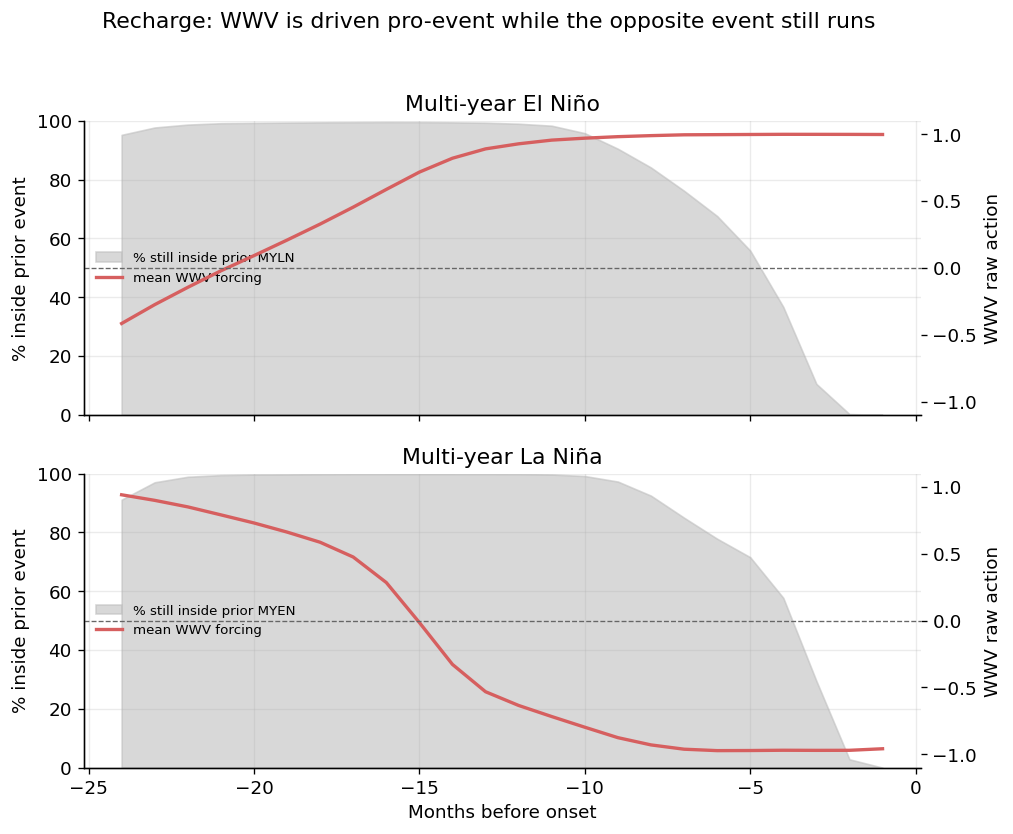

In [116]:
pre = np.arange(-LEAD, 0)                      # this figure is pre-onset only
fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
for ax, p in zip(axes, CODES):
    code = CODES[p]; opp = 4 if code == 3 else 3
    ev = events[p]
    Lb  = np.stack([labels[s, r, t0 - LEAD:t0]                    for (s, r, t0) in ev])   # [n,LEAD]
    Wwv = np.stack([raw[s, r, t0 - LEAD:t0, names.index("WWV")]   for (s, r, t0) in ev])   # [n,LEAD]
    frac = 100 * (Lb == opp).mean(0)
    ax.fill_between(pre, 0, frac, color="0.75", alpha=0.6,
                    label=f"% still inside prior {'MYLN' if opp==4 else 'MYEN'}")
    ax.set_ylabel("% inside prior event"); ax.set_ylim(0, 100)
    ax2 = ax.twinx(); ax2.grid(False)
    ax2.plot(pre, Wwv.mean(0), color="#D65F5F", lw=2, label="mean WWV forcing")
    ax2.axhline(0, color="0.4", lw=0.8, ls="--"); ax2.set_ylabel("WWV raw action"); ax2.set_ylim(-1.1, 1.1)
    ax.set_title(PHASE_LABELS[p])
    l1, la1 = ax.get_legend_handles_labels(); l2, la2 = ax2.get_legend_handles_labels()
    ax.legend(l1 + l2, la1 + la2, fontsize=8, frameon=False, loc="center left")
axes[-1].set_xlabel("Months before onset")
fig.suptitle("Recharge: WWV is driven pro-event while the opposite event still runs", y=1.01)
fig.savefig(OUTDIR / "07b_precursor_recharge.png")
plt.show()

## 7. Robustness caveats

- **Reward-band question.** Median event duration sits right at the reward's
  duration ceiling (24 months). A reviewer will ask whether the agent found genuine
  precursors or is exploiting that band — flagged here explicitly.
- **Saturation.** The policy is at the ±1 bound most of the time, so the composites
  above report the *direction* of each driver, not a graded magnitude.
- **Clustering.** All CIs are across the n≈10 training seeds; pooling individual
  events would understate the uncertainty by ~9–29×.
- **The σ unit in §3b is model, not observed.** The cell below compares the unforced
  baseline against ORAS5 (1979–2024). The model under-disperses, so σ counts in the
  state figure are optimistic relative to the real world by the printed ratio.

In [117]:
dur = {}
for p, code in CODES.items():
    d_list = [L for si in range(S) for ri in range(R)
              for _s, _e, L in _find_continuous_runs((labels[si, ri] == code).astype(int))]
    dur[p] = d_list
    print(f"{PHASE_LABELS[p]:22s}: median duration = {np.median(d_list):.1f} mo "
          f"(reward ceiling = 24)  |  n = {len(d_list)} events")
print(f"\nSaturation |raw|>0.99 (post-spinup): {100*(np.abs(raw[:,:,spin:])>0.99).mean():.1f}%")
print(f"Figures + tables written to: {OUTDIR}")

Multi-year El Niño    : median duration = 23.0 mo (reward ceiling = 24)  |  n = 6368 events
Multi-year La Niña    : median duration = 24.0 mo (reward ceiling = 24)  |  n = 6306 events

Saturation |raw|>0.99 (post-spinup): 74.6%
Figures + tables written to: ../plots/model10/precursor


In [118]:
# Does the unforced model reproduce observed variability? The state figure (§3b) is
# normalized by baseline sigma, so this sets how far "sigma" is from the real world.
import xarray as xr

ds = xr.open_dataset(Path("..") / "data" / "XRO_indices_oras5.nc")   # ORAS5, 1979-2024
obs_sd = np.array([ds[nm].values.astype(float).std() for nm in vnames])

chk = pd.DataFrame({"ORAS5_sd": obs_sd, "baseline_sd": bsig,
                    "ratio": bsig / obs_sd}, index=vnames).round(2)
chk.index.name = "variable"
chk.to_csv(OUTDIR / "baseline_vs_oras5_sigma.csv")

print(f"model/obs sigma ratio: median {np.median(bsig/obs_sd):.2f}  "
      f"range {(bsig/obs_sd).min():.2f}-{(bsig/obs_sd).max():.2f}")
print("-> the unforced XRO model under-disperses; a curve at k sigma in §3b is"
      f" ~{np.median(bsig/obs_sd):.2f}k sigma of OBSERVED variability.\n")
chk

model/obs sigma ratio: median 0.74  range 0.59-1.02
-> the unforced XRO model under-disperses; a curve at k sigma in §3b is ~0.74k sigma of OBSERVED variability.



,ORAS5_sd,baseline_sd,ratio
variable,,,
Nino34,0.89,0.70,0.78
WWV,6.98,7.11,1.02
NPMM,0.41,0.31,0.75
SPMM,0.44,0.33,0.74
IOB,0.24,0.18,0.74
IOD,0.48,0.28,0.59
SIOD,0.39,0.28,0.72
TNA,0.37,0.27,0.71
ATL3,0.44,0.33,0.75


## Takeaways

- **The pre-onset fingerprint is stable but shallow.** 3- and 6-month windows give the
  same signs (9/9, both phases): the few-months view tells you *which way* each driver
  points, not *how* the event was built.
- **The mechanism lives 8–18 months out.** WWV, SPMM and the inter-basin modes commit
  their sign well over a year before onset; IOD and SASD move latest. This *sequencing*
  is the RL-specific insight.
- **It is a recharge strategy.** A large fraction of the lead window sits inside the
  prior opposite event, during which the agent already drives WWV in the next event's
  direction — the recharge-oscillator signature.
- **Sustainment is not sustained forcing.** After onset the agent releases its drivers
  quickly — TNA flips sign at +2 months, SIOD/SASD/IOB at +3–8, SPMM/ATL3/WWV at
  +9–12, only IOD is held to +17–21 — yet Niño3.4 keeps growing to its peak at
  **+12/+13 months** (+3.4 σ MYEN, −2.3 σ MYLN in unforced-model units). The event is
  carried by the state it was handed: WWV peaks at +2/+3, discharges through zero at
  +16/+19 and overshoots to −2.3 σ, while IOB and TNA peak last (+20–22). By the time
  the drivers have reversed they are already recharging the *next*, opposite event —
  70–77% of events flip phase within 6 months of ending.
- **The controlled system sits far outside the model's unforced range.** Referenced to
  the paired no-agent baseline, the agent holds Niño3.4 variability at 2.2× unforced
  and shifts the mean state by +0.28 σ; at onset the inter-basin modes already sit at
  2.0–2.6 σ. Against *observed* variability these numbers shrink by ~25% (§7) — quote
  the observed-scaled version outside this notebook.
- **Seasonality is not what drives the composites.** Actions are plotted raw and states
  are not de-seasonalized: the policy's seasonal swing is ≤0.15 on a ±1 range, and the
  XRO indices' seasonal cycle in the mean is 2–6% of σ. The real seasonality here is
  ENSO's variance phase-locking, which is deliberately retained.
- Treat all of this as the **agent's learned strategy**; bridge to observed ENSO
  precursors only where they align, and keep the reward-ceiling caveat in view.